# E-commerce Customer Segmentation & Retention Opportunity Analysis

## 1. Project Overview

### Dataset Context

This project uses the **Online Retail II UCI** dataset hosted on **Kaggle**.

Dataset source: [Kaggle - Online Retail II UCI](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)

The dataset contains transaction-level records from an anonymized UK-based non-store online retail business between **December 2009 and December 2011**. The company mainly sells all-occasion giftware products, and many of its customers are wholesalers.

Each row represents a product line within an invoice, including information such as invoice number, product code, product description, quantity, invoice date, unit price, customer ID, and country.

### Business Context

For an online retail business, not all customers contribute equally to revenue. Some customers purchase frequently and generate high revenue, while others may buy once and never return.

Because of this, treating all customers the same can lead to inefficient CRM and retention efforts.

This project uses customer transaction data to identify customer segments based on purchase behavior and suggest practical CRM actions for each segment.

### Main Business Question

Which customer segments should the business prioritize for retention, reactivation, and revenue growth?

### Analytical Approach

This project uses a simple and interpretable **RFM segmentation** approach:

- **Recency**: How recently a customer purchased
- **Frequency**: How often a customer purchased
- **Monetary**: How much revenue a customer generated

The goal is to translate transaction data into customer segments such as high-value customers, loyal customers, new customers, at-risk customers, and inactive customers.

### Expected Output

The final output will include:

- A cleaned transaction dataset
- Customer-level RFM metrics
- Customer segments
- Segment-level performance summary
- CRM recommendations for retention, reactivation, and revenue growth

## 2. Setup and Data Loading

This section imports the required Python libraries and loads the transaction dataset for initial inspection.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("data/online_retail_II.csv.gz")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Initial Preview

The dataset was loaded successfully. Each row represents one product line within an invoice, including product information, transaction quantity, invoice date, unit price, customer ID, and country.

## 3. Initial Data Inspection

This section checks the dataset structure and identifies the main data quality issues before cleaning.

### 3.1 Dataset Size

First, I check the number of rows and columns in the dataset.

In [2]:
basic_structure = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})

basic_structure

,Metric,Value
0,Rows,1067371
1,Columns,8


### 3.2 Column Overview

Next, I check each column's data type and missing values.

In [3]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values,
    "Missing %": (df.isna().mean() * 100).round(2).values
})

column_summary

,Column,Data Type,Missing Values,Missing %
0,Invoice,object,0,0.00
1,StockCode,object,0,0.00
2,Description,object,4382,0.41
3,Quantity,int64,0,0.00
4,InvoiceDate,object,0,0.00
5,Price,float64,0,0.00
6,Customer ID,float64,243007,22.77
7,Country,object,0,0.00


### 3.3 Key Data Quality Checks

Before cleaning, I check duplicate rows, cancelled invoices, and non-positive quantity or price values.

In [4]:
data_quality_checks = pd.DataFrame({
    "Check": [
        "Duplicate rows",
        "Cancelled invoices",
        "Rows with Quantity <= 0",
        "Rows with Price <= 0"
    ],
    "Count": [
        df.duplicated().sum(),
        df["Invoice"].astype(str).str.startswith("C").sum(),
        (df["Quantity"] <= 0).sum(),
        (df["Price"] <= 0).sum()
    ]
})

data_quality_checks

,Check,Count
0,Duplicate rows,34335
1,Cancelled invoices,19494
2,Rows with Quantity <= 0,22950
3,Rows with Price <= 0,6207


### 3.4 Numeric Summary

I review the basic statistics of quantity and price to understand their ranges before cleaning.

In [5]:
df[["Quantity", "Price"]].describe().round(2)

,Quantity,Price
count,1067371.00,1067371.00
mean,9.94,4.65
std,172.71,123.55
min,-80995.00,-53594.36
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.15
max,80995.00,38970.00


### Initial Inspection Summary

The dataset contains 1,067,371 rows and 8 columns. The main data quality issues are missing customer IDs, duplicate rows, cancelled invoices, non-positive quantity values, and non-positive price values.

These issues need to be handled before building customer-level RFM metrics because the analysis requires valid customer IDs and valid purchase transactions. The `InvoiceDate` column will also be converted to datetime format in the cleaning step.

## 4. Data Cleaning

This section prepares the dataset for customer-level RFM analysis.

For this project, valid sales transactions are defined as records that:

- Have a valid customer ID
- Are not cancelled invoices
- Have positive quantity
- Have positive price
- Are not duplicate rows

These rules are used because RFM segmentation requires valid customer-level purchase transactions.

### 4.1 Create a Clean Copy

I create a separate cleaned dataframe so the original dataset remains unchanged.

In [6]:
df_clean = df.copy()

### 4.2 Apply Cleaning Rules

I remove records that are not suitable for customer-level purchase analysis.

In [7]:
rows_before = df_clean.shape[0]

df_clean = df_clean.dropna(subset=["Customer ID"])
df_clean["Customer ID"] = df_clean["Customer ID"].astype(int)

df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["Price"] > 0]
df_clean = df_clean.drop_duplicates()

rows_after = df_clean.shape[0]

rows_before, rows_after

(1067371, 779425)

### 4.3 Convert Date Column

The invoice date column is converted to datetime format so it can be used later to calculate recency.

In [8]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean["InvoiceDate"].min(), df_clean["InvoiceDate"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

### 4.4 Create Revenue Column

Revenue is calculated at the invoice-line level using quantity and unit price.

In [9]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]

df_clean[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


### 4.5 Cleaning Summary

I compare the number of rows before and after applying all cleaning rules, including removing missing customer IDs, cancelled invoices, non-positive quantity or price values, and duplicate rows.

The row counts are summarized at an overall level because some data quality issues can overlap.

In [10]:
cleaning_summary = pd.DataFrame({
    "Stage": ["Before cleaning", "After cleaning", "Rows removed"],
    "Rows": [rows_before, rows_after, rows_before - rows_after]
})

cleaning_summary

,Stage,Rows
0,Before cleaning,1067371
1,After cleaning,779425
2,Rows removed,287946


### 4.6 Post-Cleaning Checks

I check the cleaned dataset to confirm that the main data quality issues have been handled.

In [11]:
post_cleaning_checks = pd.DataFrame({
    "Check": [
        "Missing Customer ID",
        "Cancelled invoices",
        "Rows with Quantity <= 0",
        "Rows with Price <= 0",
        "Duplicate rows"
    ],
    "Count": [
        df_clean["Customer ID"].isna().sum(),
        df_clean["Invoice"].astype(str).str.startswith("C").sum(),
        (df_clean["Quantity"] <= 0).sum(),
        (df_clean["Price"] <= 0).sum(),
        df_clean.duplicated().sum()
    ]
})

post_cleaning_checks

,Check,Count
0,Missing Customer ID,0
1,Cancelled invoices,0
2,Rows with Quantity <= 0,0
3,Rows with Price <= 0,0
4,Duplicate rows,0


### Cleaning Summary Interpretation

After cleaning, the dataset contains 779,425 valid purchase transaction lines. The cleaning process removed records with missing customer IDs, cancelled invoices, non-positive quantity or price values, and duplicate rows.

The post-cleaning checks confirm that these issues have been handled. This cleaned dataset is now suitable for customer-level RFM analysis.

## 5. Exploratory Business Analysis

This section explores the cleaned transaction data before building customer segments.

The goal is to understand the overall business size, revenue trend, and whether revenue is concentrated among a small group of customers.

### 5.1 Business Overview

I calculate basic business metrics from the cleaned dataset, including total revenue, number of customers, number of orders, and transaction date range.

In [12]:
business_overview = pd.DataFrame({
    "Metric": [
        "Total revenue",
        "Number of customers",
        "Number of orders",
        "Number of products",
        "Start date",
        "End date"
    ],
    "Value": [
        round(df_clean["Revenue"].sum(), 2),
        df_clean["Customer ID"].nunique(),
        df_clean["Invoice"].nunique(),
        df_clean["StockCode"].nunique(),
        df_clean["InvoiceDate"].min(),
        df_clean["InvoiceDate"].max()
    ]
})

business_overview

,Metric,Value
0,Total revenue,17374804.27
1,Number of customers,5878
2,Number of orders,36969
3,Number of products,4631
4,Start date,2009-12-01 07:45:00
5,End date,2011-12-09 12:50:00


### Business Overview Interpretation

After cleaning, the dataset contains 779,425 valid transaction lines, 5,878 customers, and 36,969 orders.

This provides a solid customer-level transaction base for RFM segmentation.

### 5.2 Monthly Revenue Trend

I aggregate revenue by month to understand how sales changed over time.

First, I create a monthly revenue table by grouping cleaned transactions by invoice month.

In [13]:
df_clean["InvoiceMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue = df_clean.groupby("InvoiceMonth")["Revenue"].sum().reset_index()

monthly_revenue.head()

,InvoiceMonth,Revenue
0,2009-12,683504.010
1,2010-01,555802.672
2,2010-02,504558.956
3,2010-03,696978.471
4,2010-04,591982.002


Next, I plot monthly revenue to inspect the overall revenue trend and possible seasonality.

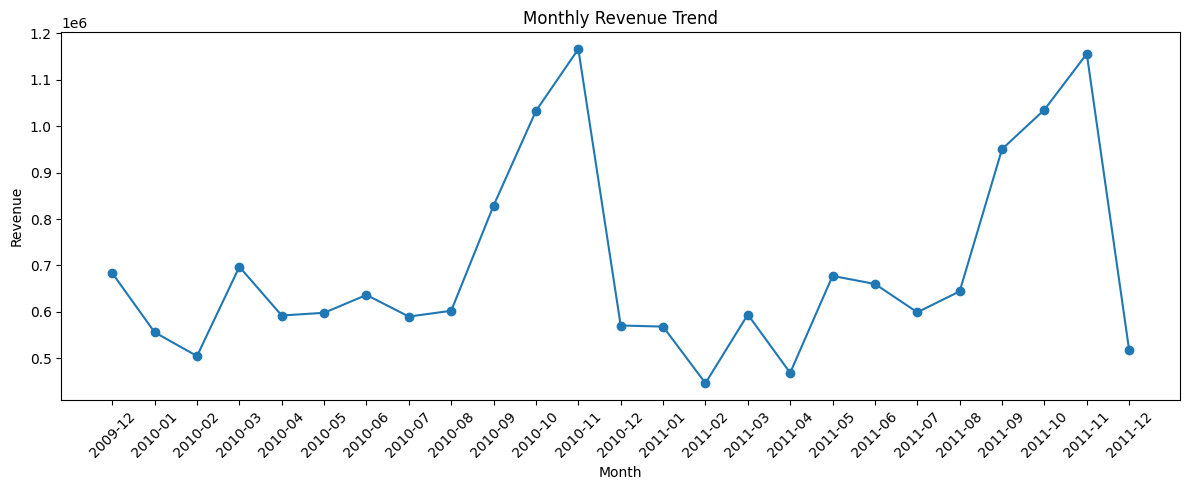

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["InvoiceMonth"], monthly_revenue["Revenue"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

### Monthly Revenue Interpretation

Monthly revenue fluctuates over time and shows stronger sales activity around the later months of each year, especially around October and November.

The sharp drop in December 2011 should be interpreted carefully because the dataset only includes transactions up to early December 2011, not the full month.

This trend provides useful context before RFM analysis because customer recency and purchase activity should be interpreted within the dataset's transaction period.

### 5.3 Customer Revenue Concentration

I aggregate revenue at the customer level to check whether revenue is evenly distributed across customers or concentrated among a smaller group.

In [15]:
customer_revenue = (
    df_clean.groupby("Customer ID")["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

customer_revenue.head(10)

,Customer ID,Revenue
5692,18102,580987.04
2277,14646,528602.52
1789,14156,313437.62
2538,14911,291420.81
5050,17450,244784.25
1331,13694,195640.69
5109,17511,172132.87
4061,16446,168472.50
4295,16684,147142.77
68,12415,144458.37


I calculate how much revenue is contributed by the top 10% of customers.

In [16]:
top_10_percent_count = int(len(customer_revenue) * 0.10)

top_10_percent_revenue = customer_revenue.head(top_10_percent_count)["Revenue"].sum()

total_revenue = customer_revenue["Revenue"].sum()

top_10_percent_share = round((top_10_percent_revenue / total_revenue) * 100, 2)

top_customer_summary = pd.DataFrame({
    "Metric": [
        "Total customers",
        "Top 10% customer count",
        "Top 10% revenue share"
    ],
    "Value": [
        f"{len(customer_revenue):,}",
        f"{top_10_percent_count:,}",
        f"{top_10_percent_share}%"
    ]
})

top_customer_summary

,Metric,Value
0,Total customers,"5,878"
1,Top 10% customer count,587
2,Top 10% revenue share,63.9%


### Customer Revenue Interpretation

Customer revenue is concentrated among a smaller group of customers. The top 10% of customers contribute 63.9% of total revenue.

This supports the need for customer segmentation because high-value, low-value, active, and inactive customers should not be treated the same in CRM planning.

## 6. RFM Metrics and Customer Segmentation

This section builds customer-level RFM metrics and assigns customers into simple, interpretable segments.

RFM stands for:

- **Recency**: how recently a customer purchased
- **Frequency**: how often a customer purchased
- **Monetary**: how much revenue a customer generated

These metrics are used to identify customer groups for CRM and retention actions.

### 6.1 Create Customer-Level RFM Table

I aggregate the cleaned transaction data at the customer level to calculate Recency, Frequency, and Monetary value.

In [17]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
}).reset_index()

rfm.columns = ["Customer ID", "Recency", "Frequency", "Monetary"]

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


### RFM Table Interpretation

The RFM table now has one row per customer.

Each customer is described by how recently they purchased, how frequently they purchased, and how much revenue they generated.

### 6.2 Review RFM Metrics

I review the basic statistics of the RFM metrics before creating customer scores.

In [18]:
rfm[["Recency", "Frequency", "Monetary"]].describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


### RFM Metrics Observation

The RFM metrics show that customer behavior is uneven. Frequency and Monetary values have much higher maximum values than their median values, which suggests that a small group of customers purchases much more frequently and generates much more revenue than the average customer.

### 6.3 Create RFM Scores

I convert Recency, Frequency, and Monetary values into scores from 1 to 5.

For Recency, a lower number of days is better, so more recent customers receive a higher score.

For Frequency and Monetary, higher values are better, so more frequent and higher-spending customers receive higher scores.

In [19]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,2,5,5,12
1,12347,2,8,4921.53,5,4,5,14
2,12348,75,5,2019.40,3,4,4,11
3,12349,19,4,4428.69,5,3,5,13
4,12350,310,1,334.40,2,1,2,5


### RFM Scoring Interpretation

Each customer now has an R score, F score, M score, and total RFM score.

The total score gives a simple way to compare customer value and engagement level, but the individual R, F, and M scores are more useful for assigning business-oriented customer segments.

### 6.4 Assign Customer Segments

I assign customers into simple segments based on their RFM scores.

The goal is not to create a complex model, but to create interpretable customer groups that can support CRM actions.

In [20]:
def assign_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 4:
        return "Loyal Customers"
    elif row["R_Score"] >= 4 and row["F_Score"] in [2, 3]:
        return "Potential Loyalists"
    elif row["R_Score"] >= 4 and row["F_Score"] == 1:
        return "New Customers"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Hibernating"
    else:
        return "Needs Attention"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,12,77556.46,2,5,5,12,At Risk
1,12347,2,8,4921.53,5,4,5,14,Champions
2,12348,75,5,2019.40,3,4,4,11,Loyal Customers
3,12349,19,4,4428.69,5,3,5,13,Potential Loyalists
4,12350,310,1,334.40,2,1,2,5,Hibernating


### 6.5 Segment Summary

I summarize each customer segment by customer count, revenue contribution, and average RFM metrics.

In [21]:
segment_summary = rfm.groupby("Segment").agg({
    "Customer ID": "count",
    "Monetary": ["sum", "mean"],
    "Recency": "mean",
    "Frequency": "mean",
    "RFM_Score": "mean"
}).reset_index()

segment_summary.columns = [
    "Segment",
    "Customers",
    "Total Revenue",
    "Avg Monetary",
    "Avg Recency",
    "Avg Frequency",
    "Avg RFM Score"
]

segment_summary["Customer Share (%)"] = (
    segment_summary["Customers"] / segment_summary["Customers"].sum() * 100
).round(2)

segment_summary["Revenue Share (%)"] = (
    segment_summary["Total Revenue"] / segment_summary["Total Revenue"].sum() * 100
).round(2)

segment_summary = segment_summary.sort_values("Total Revenue", ascending=False).reset_index(drop=True)

segment_summary.round(2)

,Segment,Customers,Total Revenue,Avg Monetary,Avg Recency,Avg Frequency,Avg RFM Score,Customer Share (%),Revenue Share (%)
0,Champions,1289,11819626.88,9169.61,19.72,17.15,13.91,21.93,68.03
1,Loyal Customers,708,1895631.38,2677.45,83.93,7.77,11.46,12.04,10.91
2,At Risk,825,1590384.58,1927.74,368.88,4.94,8.40,14.04,9.15
3,Potential Loyalists,711,814304.39,1145.29,25.62,2.59,9.68,12.10,4.69
4,Hibernating,1526,655444.68,429.52,458.75,1.25,4.57,25.96,3.77
5,Needs Attention,652,543791.94,834.04,108.98,2.10,7.53,11.09,3.13
6,New Customers,167,55620.42,333.06,29.55,1.00,6.87,2.84,0.32


### Segment Summary Interpretation

The segment summary shows that customer value is highly concentrated in the Champions segment. Champions represent 21.93% of customers but contribute 68.03% of total revenue.

Hibernating customers are the largest segment by customer count, representing 25.96% of customers, but they contribute only 3.77% of revenue. This suggests that not all large customer groups are equally valuable.

The At Risk segment contributes 9.15% of revenue and has a high average recency, which makes it a potential target for reactivation or win-back campaigns.

### 6.6 Segment Count Chart

I visualize the number of customers in each segment to make the segment distribution easier to read.

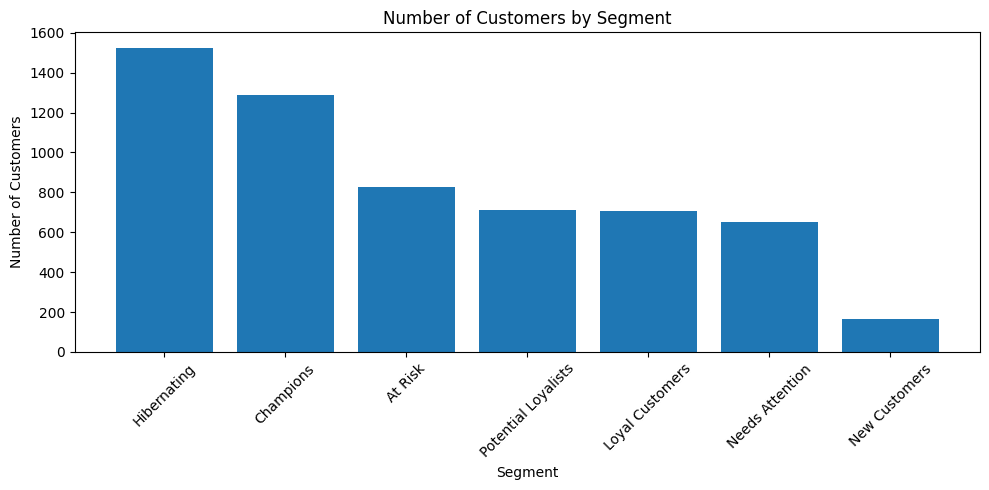

In [22]:
segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(segment_counts.index, segment_counts.values)
plt.xticks(rotation=45)
plt.title("Number of Customers by Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### RFM Segmentation Interpretation

The RFM segmentation creates practical customer groups based on purchase recency, frequency, and monetary value.

These segments will be used in the next section to define CRM recommendations for retention, reactivation, and revenue growth.

## 7. CRM Recommendations by Segment

This section translates the RFM segments into practical CRM recommendations.

The goal is to connect customer behavior patterns with possible retention, reactivation, and revenue growth actions.

| Segment | Data Insight | Recommended CRM Action | KPI to Track |
|---|---|---|---|
| Champions | 21.93% of customers but 68.03% of revenue. Low average recency and high frequency. | Prioritize retention with VIP benefits, early access, referral incentives, or personalized offers. | Repeat purchase rate, average order value, referral rate |
| Loyal Customers | 12.04% of customers and 10.91% of revenue. Regular purchase behavior. | Use loyalty rewards, bundle offers, and personalized product recommendations. | Purchase frequency, revenue per customer, repeat purchase rate |
| At Risk | 14.04% of customers and 9.15% of revenue. High average recency of 368.88 days. | Run win-back campaigns with limited-time offers or personalized reactivation messages. | Reactivation rate, win-back conversion rate |
| Potential Loyalists | 12.10% of customers and 4.69% of revenue. Recent customers with moderate frequency. | Encourage repeat purchase through onboarding, product recommendations, or second-purchase incentives. | Second purchase rate, purchase frequency |
| New Customers | 2.84% of customers and 0.32% of revenue. New customers with limited history. | Send post-purchase follow-up and first repeat-purchase incentive. | 30-day repeat purchase rate, second purchase rate |
| Needs Attention | 11.09% of customers and 3.13% of revenue. Moderate engagement but unclear loyalty. | Test reminder campaigns, product recommendations, or light promotional offers. | Email click rate, conversion rate, repeat purchase rate |
| Hibernating | 25.96% of customers but only 3.77% of revenue. Very high average recency and low frequency. | Use low-cost reactivation campaigns, or deprioritize if campaign ROI is weak. | Reactivation rate, campaign ROI, unsubscribe rate |

### CRM Recommendation Interpretation

The Champions segment should be prioritized for retention because it contributes the largest share of revenue.

The At Risk segment is important for reactivation because these customers have generated meaningful revenue but have not purchased recently.

Hibernating customers form the largest group by customer count but contribute a small share of revenue, so reactivation efforts for this group should be low-cost and carefully measured.

## 8. Limitations and Next Steps

### Limitations

This analysis is based only on transaction data. It does not include customer demographics, acquisition channels, website behavior, email engagement, or campaign exposure data.

Because of this, the recommendations should be interpreted as CRM opportunities based on purchase behavior, not as evidence of causal marketing impact.

The dataset also covers a historical period from December 2009 to December 2011, so the results should be viewed as an analytical exercise rather than a current business diagnosis.

### Next Steps

If more data were available, the analysis could be extended by:

- Adding customer acquisition channel data to compare customer value by source
- Including email or campaign engagement data to evaluate CRM response
- Tracking repeat purchase rate after each campaign
- Building a simple churn or reactivation model after enough behavioral data is collected
- Creating a dashboard to monitor segment size, revenue share, and retention KPIs over time

## 9. Final Conclusion

This project used Python to analyze online retail transaction data and segment customers based on RFM metrics.

The analysis shows that customer value is not evenly distributed. The Champions segment represents 21.93% of customers but contributes 68.03% of total revenue, making it the most important group for retention and loyalty actions.

The At Risk segment is also important because these customers have generated meaningful revenue but have not purchased recently, which makes them a potential target for win-back campaigns.

Hibernating customers form the largest segment by customer count but contribute only 3.77% of revenue, so reactivation efforts for this group should be low-cost and carefully measured.

Overall, RFM segmentation provides a simple and interpretable way to prioritize CRM actions for retention, reactivation, and revenue growth.